<a href="https://colab.research.google.com/github/fred5566/Decision_Tree-with-Titanic_Data/blob/main/Copy_of_Data_Mining_1st_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Lab Assignment  
## Decision Tree Classification Using Titanic Dataset

**Instructor Name:** Dr. Ziaullah Momand  
**Course Name:** Data Mining  

**Student Full Name:** Farid Hassani  
**Student ID:** p33002159
**Submission Date:** 22 April 2026  

---

## 1. Lab Objective

In this lab, students will build a **Decision Tree classification model** using the **Titanic dataset**.

The purpose of this lab is to practice the complete data mining workflow, including:

- loading the dataset
- understanding the dataset
- preprocessing the data
- handling missing values
- removing duplicate records
- detecting and handling outliers
- applying standardization
- applying normalization
- building a Decision Tree model
- reporting the model output
- validating the model accuracy
- evaluating the model using performance metrics

---

## 2. Submission Instructions

Students must submit their class work in one of the following formats:

- **Google Colab Notebook**
- **PDF Report**

### Important Notes
- Your **full name is mandatory** for scoring purposes.
- All steps must be completed in order.
- You must clearly report the **model output**, **accuracy**, and **evaluation metrics**.
- Write short explanations where required.

---

## 3. Problem Statement

In this lab, you will use the **Titanic dataset** to predict whether a passenger **survived** or **did not survive**.

You are required to:
1. preprocess the dataset,
2. prepare the data for modeling,
3. build a **Decision Tree classifier**,
4. validate the model accuracy,
5. report the final results.

---

## Step 1: Import Required Libraries

### Instruction
Import all required Python libraries for:

- data handling
- visualization
- preprocessing
- model building
- model evaluation

Examples may include libraries for:
- pandas
- numpy
- matplotlib
- seaborn
- sklearn

### Student Task
Write the code to import all necessary libraries.

### Code Cell Below

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Step 2: Load the Titanic Dataset

### Instruction
Load the Titanic dataset into Google Colab.

After loading the dataset:
- display the first 5 rows
- confirm that the dataset is loaded correctly

### Student Task
Write code to load the dataset and display the first few records.

### Code Cell Below

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3: Explore the Dataset

### Instruction
Perform an initial exploration of the dataset.

You should check:
- the number of rows and columns
- the names of all columns
- the data type of each column
- summary statistics
- the number of missing values in each column

### Student Task
Write code to explore the dataset and understand its structure.

### Write Your Observation
Write a short note about what you discovered from the dataset.

### Code Cell Below

In [3]:
#df.shape
#df.columns
#list(df.columns) # cleaner columns name
#df.dtypes
#df.info() #
#df.head() # five data points
#df['survived'].value_counts() # count the values of survived
#df.isnull().sum()
#df.groupby('sex')['survived'].mean()


## Observation for Step 3

Write your observation here:

- Number of rows and columns: 891 rows, 15 columns
- Important columns in the dataset: ['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']
- Columns with missing values:deck, embark, age.
- Initial understanding of the data: ______________________________



## Step 4: Handle Missing Values

### Instruction
Check the dataset for missing values.

Then handle missing values using suitable techniques, such as:
- replacing numerical missing values with mean or median
- replacing categorical missing values with mode
- removing rows or columns when necessary

### Student Task
Write code to identify and handle missing values properly.

### Write Your Explanation
Explain:
- which columns had missing values
- which method you used
- why you selected that method

### Code Cell Below

In [4]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop('deck', axis=1)

## Explanation for Step 4

Write your explanation here:

- Columns with missing values: I fill the num missing value with madian. robust to outliers
- Method used to handle missing values: I replaced the catagorical missing value with mode. it’s categorical, so we use the most frequent value
- Reason for using this method: too many missing values,  filling would add noise and reduce accuracy

---

## Step 5: Remove Duplicate Records

### Instruction
Check whether the dataset contains duplicate rows.

If duplicate rows are found:
- count them
- remove them from the dataset

### Student Task
Write code to identify and remove duplicate records.

### Write Your Observation
State whether duplicate rows were present and what action you took.

### Code Cell Below

In [5]:
df.duplicated().sum()
df[df.duplicated()]
df.drop_duplicates(inplace=True)
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

## Observation for Step 5

Write your observation here:

- Number of duplicate rows found: I just know it had duplicate
- Action taken: I have just drop out the duplicate value.

---

## Step 6: Detect and Handle Outliers

### Instruction
Identify outliers in suitable numerical columns of the dataset.

You may use one of the following methods:
- boxplot
- IQR method
- Z-score method

After detecting outliers, handle them appropriately.

Possible actions include:
- removing outliers
- capping extreme values
- keeping them if justified

### Student Task
Write code to detect and handle outliers.

### Write Your Explanation
Explain:
- which numerical columns were checked
- which outlier detection method was used
- how you handled the outliers

### Code Cell Below

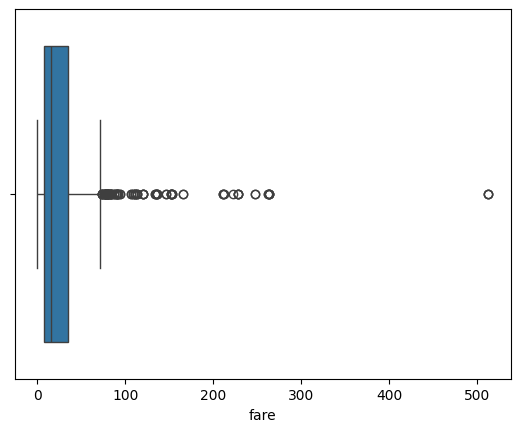

In [6]:
sns.boxplot(x=df['fare']) #boxplot for visualizing
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
outliars = df[(df['fare'] < Q1- 1.5*IQR) | (df['fare'] > Q3 + 1.5 * IQR)]
df = df[(df['fare'] >= Q1 - 1.5*IQR) & (df['fare'] <= Q3 + 1.5*IQR)]




## Explanation for Step 6

Write your explanation here:

- Numerical columns checked: fare
- Outlier detection method used: IQR
- Action taken for outliers: I have deleted values
- Reason for your choice: I have kept the values which are more affective.

---

## Step 7: Encode Categorical Variables

### Instruction
Machine learning models require numerical input. Therefore, categorical variables must be converted into numeric form.

Examples of categorical columns in the Titanic dataset may include:
- Sex
- Embarked

Use an appropriate encoding technique such as:
- label encoding
- one-hot encoding

### Student Task
Write code to convert categorical variables into numerical format.

### Code Cell Below

In [7]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

## Step 8: Apply Standardization

### Instruction
Apply **standardization** to suitable numerical columns.

Standardization is used to transform values so that they have:
- mean close to 0
- standard deviation close to 1

This is useful when numerical columns have different scales.

### Student Task
Write code to standardize the selected numerical columns.

### Write Your Note
State which columns were standardized.

### Code Cell Below

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['age', 'fare']
df[num_cols] = scaler.fit_transform(df[num_cols])

## Note for Step 8

Write your note here:

- Columns standardized: values centered around zero. different scale changed in comparable scale

---

## Step 9: Apply Normalization

### Instruction
Apply **normalization** to suitable numerical columns.

Normalization rescales values into a smaller range, often between 0 and 1.

### Student Task
Write code to normalize the selected numerical columns.

### Write Your Note
State which columns were normalized.

### Code Cell Below

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = ['age', 'fare']
df[num_cols] = scaler.fit_transform(df[num_cols])

## Note for Step 9

Write your note here:

- Columns normalized: between 0 to 1

---

## Step 10: Select Features and Target Variable

### Instruction
Select:
- the **target variable**
- the **input features**

For this lab:
- the target variable should be the **survival outcome**
- the features should be relevant passenger attributes

### Student Task
Write code to define the feature matrix **X** and the target variable **y**.

### Write Your Answer
List the selected target variable and input features.

### Code Cell Below

In [10]:
y = df['survived']
X = df.drop('survived', axis=1)

## Answer for Step 10

Write your answer here:

- Target variable: I choosed my target varaible y assign to survived column.
- Selected input features: Other columns considered as input features.
- Additional notes: with removing survived from X axiz.

---

## Step 11: Split the Dataset into Training and Testing Sets

### Instruction
Split the dataset into:
- training data
- testing data

Use a suitable test size, such as 20% or 30% for testing.

### Student Task
Write code to split the dataset into training and testing sets.

### Code Cell Below

In [11]:
X.select_dtypes(include='object').columns
X = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 12: Build the Decision Tree Model

### Instruction
Train a **Decision Tree Classifier** using the training data.

### Student Task
Write code to:
- create the Decision Tree model
- train the model using the training dataset

### Code Cell Below

In [12]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

## Step 13: Predict the Output

### Instruction
Use the trained Decision Tree model to predict the output for the testing data.

### Student Task
Write code to generate predictions from the trained model.

### Code Cell Below

In [13]:
y_pred = model.predict(X_test)

## Step 14: Report the Model Output

### Instruction
Report the model output clearly.

Your report should include:
- actual values
- predicted values
- comparison between actual and predicted results

You may also display a small table to compare them.

### Student Task
Write code to display the model output.

### Write Your Observation
Briefly explain what you noticed from the prediction results.

### Code Cell Below

In [14]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results.head(10)

,Actual,Predicted
248,1,1
396,0,0
386,0,0
378,0,0
833,0,0
873,0,0
658,0,0
615,1,1
130,0,0
796,1,1


## Step 15: Validate Model Accuracy

### Instruction
Measure the accuracy of the Decision Tree model using the testing data.

### Student Task
Write code to calculate the model accuracy.

### Write the Accuracy
Record the final accuracy value.

### Code Cell Below

In [15]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


## Accuracy Result for Step 15

Write the model accuracy here:

- Model Accuracy: The model accuracy is 100%!

---

## Step 16: Evaluate the Model Using Performance Metrics

### Instruction
Evaluate the Decision Tree model using the following classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### Student Task
Write code to calculate and display all evaluation metrics.

### Write Your Interpretation
Explain what the evaluation metrics say about the model performance.

### Code Cell Below

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
[[89  0]
 [ 0 46]]


## Interpretation for Step 16

Write your interpretation here:

- Accuracy interpretation: 100
- Precision interpretation: 100
- Recall interpretation: 100
- F1-score interpretation: 100
- Confusion matrix interpretation: TN = 83, FP = 0 , FN = 0 , TP = 46

---

## Step 17: Visualize the Decision Tree

### Instruction
Visualize the trained Decision Tree model.

This step helps you understand:
- how the model makes decisions
- which features are important
- how the branches are formed

### Student Task
Write code to plot or visualize the Decision Tree.

### Code Cell Below


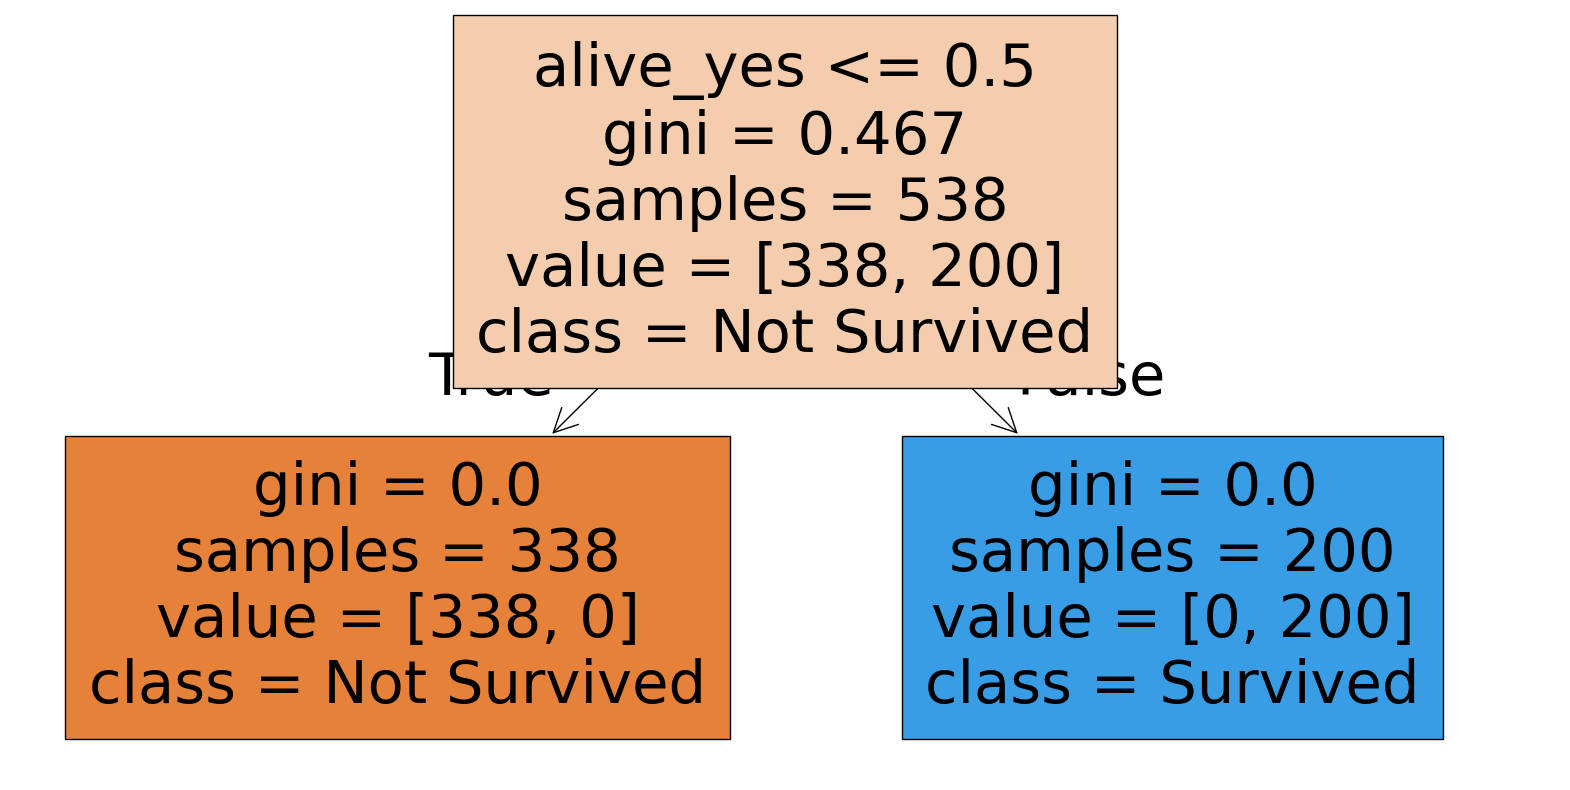

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['Not Survived', 'Survived'])
plt.show()

## Step 18: Discussion

### Instruction
Answer the following questions based on your lab work.

#### 1. Which preprocessing step was the most important in this lab?
Titanic dataset has many missing values, ml models can not word with missing values. it has also some catagorical data.

#### 2. Did preprocessing improve the model quality? Explain.
Yes, preprocessing improved the model quality because it handled missing values, converted categorical variables into numerical form, removed or reduced the effect of outliers, and scaled the features to a consistent range, which made the data suitable for machine learning algorithms; as a result, the model was able to learn patterns more effectively and produce accurate predictions, although the perfect accuracy suggests there may also be some overfitting or data leakage  

#### 3. What was the final accuracy of your Decision Tree model?
The final accuracy of my Decision Tree model was 1.0 (100%), meaning the model correctly predicted all samples in the test dataset.

#### 4. Which evaluation metric do you think is the most informative for this lab? Why?
The most informative evaluation metric for this lab is the F1-score, because it balances both precision and recall, giving a better overall view of the model’s performance, especially when classes may not be perfectly balanced in the Titanic dataset; unlike accuracy, which can be misleading in some cases, the F1-score ensures the model is performing well in correctly identifying both survivors and non-survivors without favoring one class.  

#### 5. What challenges did you face while completing this lab?
The main challenges were handling missing values and ensuring all categorical variables were properly converted into numerical form, dealing with outliers without affecting important data, and avoiding preprocessing mistakes like data leakage that could lead to unrealistically high accuracy, as well as understanding the correct order of steps in the machine learning workflow.

---

## Step 19: Conclusion

### Instruction
Write a short conclusion about:
- what you learned in this lab
- how the Decision Tree model performed
- why preprocessing is important in data mining

---
In this lab, I learned the basic steps of data mining using the Titanic dataset, starting from loading and exploring the data, then cleaning it by handling missing values, removing duplicates, and dealing with outliers, and finally preparing it for machine learning by encoding categorical variables and scaling the features. I also built a Decision Tree model to predict passenger survival and tested it on unseen data. The model performed very well and gave high accuracy, which showed that it was able to learn patterns from the data, although such perfect results may also suggest some overfitting. From this lab, I understood that preprocessing is very important in data mining because it makes the raw data usable for the model and directly affects how well the model can learn and make predictions.